## Phase 2: Dataset acquisition & preprocessing 

In [1]:
import wfdb
import os
import numpy as np
import matplotlib.pyplot as plt
from wfdb import processing, io, plot
from scipy.signal import butter, filtfilt
from collections import Counter

### Download full MIT-BIH dataset

#### The MIT-BIH database contains 48 half-hour two-channel ECG recordings sampled at 360 Hz. Each record has three files:
##### • .hea — header: metadata (sampling rate, lead names, number of samples)
##### • .dat — raw signal (binary)
##### • .atr — annotation file (beat labels and positions)

##### The wfdb library handles all three automatically.

In [7]:
# Download all 48 MIT-BIH records
wfdb.dl_database('mitdb', dl_dir='./mitdb_data')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [2]:
# Verify download
records = [f.replace('.hea','') for f in os.listdir('./mitdb_data') if f.endswith('.hea')]
print(f"Records downloaded: {len(records)}")
print("First 10:", sorted(records)[:10])

Records downloaded: 48
First 10: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109']


In [3]:
# Quick sanity check on one record
record = wfdb.rdrecord('./mitdb_data/100')
print(f"Sampling frequency: {record.fs} Hz")
print(f"Signal shape: {record.p_signal.shape}")
print(f"Lead names: {record.sig_name}")

Sampling frequency: 360 Hz
Signal shape: (650000, 2)
Lead names: ['MLII', 'V5']


### Zero-phase Butterworth bandpass filter

#### Raw ECG has three main noise sources:
##### • Baseline wander (<0.5 Hz) — slow drift from breathing and electrode movement
##### • Powerline interference (~50/60 Hz) — electrical noise from the environment
##### • Muscle artefacts (>40 Hz) — EMG noise from patient movement

#### A Butterworth filter has a maximally flat passband — it doesn't distort the signal frequencies you want to keep.

#### Zero-phase filtering (filtfilt): applies the filter TWICE for forward and backward. This cancels any time-shift (phase distortion), keeping R-peaks at their correct positions. Critical because Pan-Tompkins needs accurate peak timing.

In [4]:
#bandpass filtering function
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    nyq = 0.5 * fs          # Nyquist frequency = 180 Hz
    low = lowcut / nyq      # Normalised lower cutoff
    high = highcut / nyq    # Normalised upper cutoff
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)  # Zero-phase: no time shift

In [5]:
# Load record 100
record = wfdb.rdrecord('./mitdb_data/100')
fs = record.fs
raw_signal = record.p_signal[:, 0]  # MLII lead

In [6]:
# Apply filter
filtered_signal = bandpass_filter(raw_signal, fs=fs)

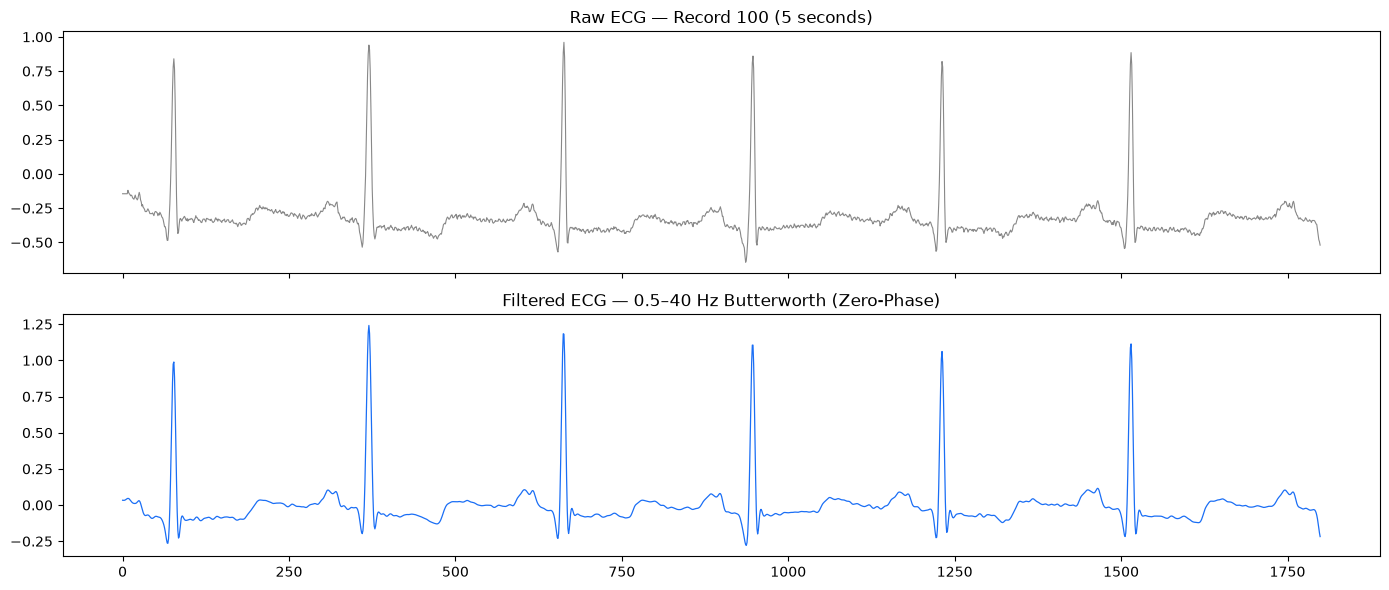

In [7]:
# Plot: evidence for supervisor
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(raw_signal[:1800], color='#888', linewidth=0.8)
axes[0].set_title('Raw ECG — Record 100 (5 seconds)')
axes[1].plot(filtered_signal[:1800], color='#1a6ef5', linewidth=0.9)
axes[1].set_title('Filtered ECG — 0.5–40 Hz Butterworth (Zero-Phase)')
plt.tight_layout()
plt.savefig('filtering_comparison.png', dpi=150)
plt.show()

### R-peak detection via GQRS (WFDB)

#### The Pan-Tompkins algorithm (1985) is the gold-standard real-time QRS detector. It works in 5 steps:
##### 1. Bandpass filter — already done above
##### 2. Differentiate — emphasises the steep QRS slope
##### 3. Square — makes all values positive, amplifies large slopes
##### 4. Moving-window integration — smooths into a hump around each QRS
##### 5. Adaptive thresholding — detects peaks above a dynamic threshold
#### But I used GQRS instead of Pan-Tompkins alogrithm (1985)
#### The wfdb library's gqrs_detect() implements this. You get back an array of sample indices where R-peaks occur.
#### GQRS is the open-source QRS detector bundled with the WFDB software package. It applies bandpass filtering followed by adaptive-threshold peak detection to locate R-peaks in real time. Here it is used only to validate detection quality against the expert reference annotations (reported below as sensitivity and positive predictivity on record 100). For the classification pipeline itself, beats are segmented around the **expert reference R-peak annotations** (`annotation.sample`), not the detected peaks, so that every beat window is perfectly aligned with its ground-truth label. This follows the inter-patient practice of de Chazal et al. (2004).

In [8]:
# Load record and annotations
record = wfdb.rdrecord('./mitdb_data/100')
annotation = wfdb.rdann('./mitdb_data/100', 'atr')
signal = record.p_signal[:, 0]
fs = record.fs

In [9]:
# GQRS R-peak detection (WFDB) — illustration on record 100
qrs_inds = processing.gqrs_detect(sig=signal, fs=fs)

print(f"R-peaks detected: {len(qrs_inds)}")
print(f"Expert annotations: {len(annotation.sample)}")
print(f"First 5 detected:  {qrs_inds[:5]}")
print(f"First 5 annotated: {annotation.sample[:5]}")

R-peaks detected: 2272
Expert annotations: 2274
First 5 detected:  [ 357  650  934 1219 1502]
First 5 annotated: [ 18  77 370 662 946]


In [10]:
# Reference = actual beat annotations only (exclude non-beat markers like +, ~, |),
# using the AAMI_MAP you already defined so it's consistent with the pipeline.
BEAT_SYMBOLS = {'N','L','R','e','j','A','a','J','S','V','E','F','/','f','Q'}
is_beat   = np.array([s in BEAT_SYMBOLS for s in annotation.symbol])
ref_beats = annotation.sample[is_beat]

cmp = processing.compare_annotations(ref_sample=ref_beats, test_sample=qrs_inds,
                          window_width=int(0.05 * fs), signal=signal)
cmp.print_summary()
print(f"\nSensitivity: {cmp.sensitivity:.4f} | PPV: {cmp.positive_predictivity:.4f}")
print(f"Ref beats: {len(ref_beats)} | Detected: {len(qrs_inds)} | "
      f"TP={cmp.tp} FP={cmp.fp} FN={cmp.fn}")

2273 reference annotations, 2272 test annotations

True Positives (matched samples): 2272
False Positives (unmatched test samples): 0
False Negatives (unmatched reference samples): 1

Sensitivity: 0.9996 (2272/2273)
Positive Predictivity: 1.0000 (2272/2272)

Sensitivity: 0.9996 | PPV: 1.0000
Ref beats: 2273 | Detected: 2272 | TP=2272 FP=0 FN=1


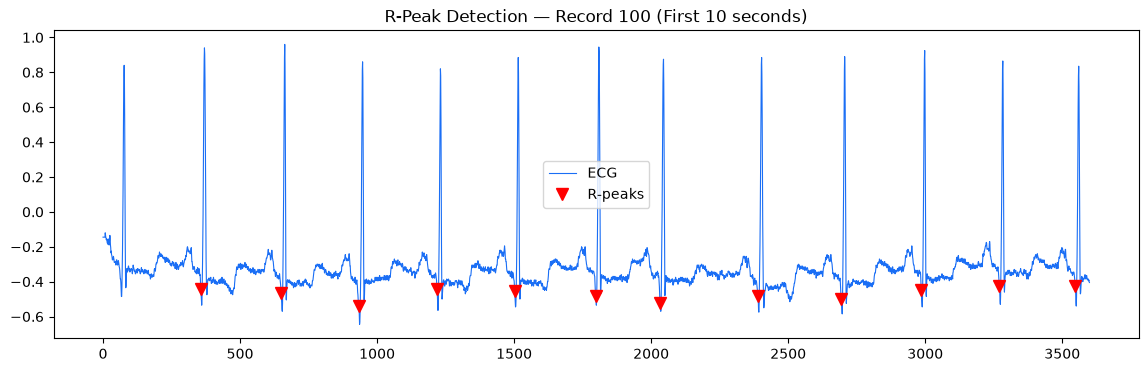

In [11]:
# Visualise
plt.figure(figsize=(14, 4))
plt.plot(signal[:3600], color='#1a6ef5', linewidth=0.8, label='ECG')
peaks_in_window = qrs_inds[qrs_inds < 3600]
plt.plot(peaks_in_window, signal[peaks_in_window], 'rv', markersize=8, label='R-peaks')
plt.title('R-Peak Detection — Record 100 (First 10 seconds)')
plt.legend()
plt.savefig('rpeak_detection.png', dpi=150)
plt.show()

### AAMI EC57 beat label mapping

#### AAMI EC57 defines 5 clinically meaningful classes:
##### • N — Normal beats (also L, R, e, j) — most common, ~75%
##### • S — Supraventricular ectopic (A, a, J, S) — originate above ventricles
##### • V — Ventricular ectopic (V, E) — originate in ventricles; clinically important
##### • F — Fusion beats (F) — part normal, part ventricular
##### • Q — Unknown/paced beats (/, f, Q) — unclassifiable or pacemaker-generated

In [12]:
# AAMI EC57 mapping
AAMI_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q'
}


In [13]:
# Process all 48 records
records = [f.replace('.hea','') for f in os.listdir('./mitdb_data') if f.endswith('.hea')]
all_labels = []

for rec in sorted(records):
    try:
        ann = wfdb.rdann(f'./mitdb_data/{rec}', 'atr')
        mapped = [AAMI_MAP.get(sym) for sym in ann.symbol]
        all_labels.extend([l for l in mapped if l is not None])
    except:
        pass


In [14]:
# Class distribution at the ANNOTATION level (before beat segmentation)
counts = Counter(all_labels)
total = sum(counts.values())
print("AAMI Class Distribution — annotation level, pre-segmentation:")
print("-" * 52)
for cls in ['N', 'S', 'V', 'F', 'Q']:
    n = counts.get(cls, 0)
    print(f"  {cls}: {n:>6,} beats  ({100*n/total:.1f}%)")
print(f"  TOTAL: {total:,} annotations")
print("\nNote: the study uses 109,454 SEGMENTED beats (see next figure);")
print("the ~40-beat gap is edge beats dropped during segmentation.")

AAMI Class Distribution — annotation level, pre-segmentation:
----------------------------------------------------
  N: 90,631 beats  (82.8%)
  S:  2,781 beats  (2.5%)
  V:  7,236 beats  (6.6%)
  F:    803 beats  (0.7%)
  Q:  8,043 beats  (7.3%)
  TOTAL: 109,494 annotations

Note: the study uses 109,454 SEGMENTED beats (see next figure);
the ~40-beat gap is edge beats dropped during segmentation.


## Phase 3: Feature Engineering & Formatting

### Beat Segmentation Around R-Peaks

#### Window: 250 ms before the R-peak, 400 ms after it.At 360 Hz that's 90 samples before, 144 after that 234 samples per beat.

#### Keep this window IDENTICAL across MLP, 1D-CNN, and LSTM so their inputs are directly comparable. Beats too close to the start/end of a recording (incomplete windows) are skipped.

In [15]:
def segment_beats(signal, r_peaks, labels, fs=360, pre_ms=250, post_ms=400):
    pre = int(pre_ms / 1000 * fs)
    post = int(post_ms / 1000 * fs)
    beats, beat_labels = [], []
    for peak, label in zip(r_peaks, labels):
        if label is None:
            continue                            # skip non-beat annotations (+, ~, |, x, etc.)
        start, end = peak - pre, peak + post
        if start < 0 or end > len(signal):
            continue                            # skip incomplete beats at signal edges
        beats.append(signal[start:end])
        beat_labels.append(label)
    return np.array(beats), np.array(beat_labels)

### Scale Preprocessing to All 48 Records

In [16]:
# Loop preprocessing across all 48 records — fixes the record-100-only limitation
all_beats = []
all_beat_labels = []
all_patient_ids = []

for rec in sorted(records):
    try:
        record = wfdb.rdrecord(f'./mitdb_data/{rec}')
        annotation = wfdb.rdann(f'./mitdb_data/{rec}', 'atr')
        signal = record.p_signal[:, 0]
        fs = record.fs

        # Filter 
        filtered = bandpass_filter(signal, fs=fs)

        # AAMI labels for this record 
        rec_labels = [AAMI_MAP.get(sym) for sym in annotation.symbol]

        # Segment beats 
        beats, beat_labels = segment_beats(filtered, annotation.sample, rec_labels)

        all_beats.append(beats)
        all_beat_labels.append(beat_labels)
        all_patient_ids.extend([rec] * len(beats))  # tag every beat with its source record
    except Exception as e:
        print(f"Skipped {rec}: {e}")

beats = np.concatenate(all_beats)
beat_labels = np.concatenate(all_beat_labels)
patient_ids = np.array(all_patient_ids)

print(f"Total beats across all records: {len(beats)}")
print(f"Total unique patients: {len(set(patient_ids))}")
print(f"Beat shape: {beats[0].shape}")

Total beats across all records: 109454
Total unique patients: 48
Beat shape: (234,)


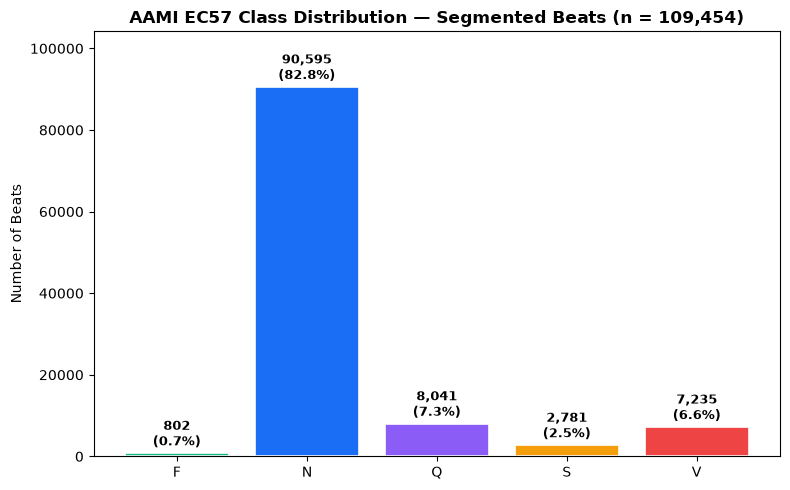

Total segmented beats: 109,454
  F:     802 (0.7%)
  N:  90,595 (82.8%)
  Q:   8,041 (7.3%)
  S:   2,781 (2.5%)
  V:   7,235 (6.6%)


In [17]:
# AAMI EC57 class distribution — computed from the ACTUAL segmented beats
from collections import Counter

counts_map = Counter(str(l) for l in beat_labels)     # real counts, not textbook values
classes = sorted(counts_map)                          # ['F','N','Q','S','V'] — alphabetical
counts  = [counts_map[c] for c in classes]
total   = sum(counts)

# Fixed colour per class so the mapping is stable regardless of order
color_map = {'F': '#10b981', 'N': '#1a6ef5', 'Q': '#8b5cf6', 'S': '#f59e0b', 'V': '#ef4444'}
colors = [color_map[c] for c in classes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(classes, counts, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title(f'AAMI EC57 Class Distribution — Segmented Beats (n = {total:,})',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Beats')

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total * 0.008,
            f'{val:,}\n({100*val/total:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"Total segmented beats: {total:,}")
for c, v in zip(classes, counts):
    print(f"  {c}: {v:>7,} ({100*v/total:.1f}%)")

### Build patient_ids and the GroupKFold Split

#### GroupKFold splits by GROUP (patient/record ID), not by individual beat. Every beat from one patient stays entirely in either train or test — never split across both.

In [18]:
from sklearn.model_selection import GroupKFold

# Now patient_ids exists and is aligned with beats/beat_labels from Task 1
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(beats, beat_labels, groups=patient_ids))

train_idx, test_idx = folds[0]
X_train, X_test = beats[train_idx], beats[test_idx]
y_train, y_test = beat_labels[train_idx], beat_labels[test_idx]

train_patients = set(patient_ids[train_idx])
test_patients = set(patient_ids[test_idx])
print(f"Train patients: {len(train_patients)} | Test patients: {len(test_patients)}")
print(f"Overlap (should be 0): {len(train_patients & test_patients)}")

Train patients: 39 | Test patients: 9
Overlap (should be 0): 0


### Three-Domain Feature Extraction

#### Three feature domains, one feature vector per beat:

##### 1. Time-domain — mean, std, skewness, kurtosis, RMS. Basic statistical shape of the beat.
##### 2. Frequency-domain — FFT-based dominant frequency and spectral energy. Rhythm characteristics.
##### 3. Wavelet-domain — db4 wavelet decomposition (level 4), energy per sub-band. Captures localised time-frequency changes that pure FFT averages away.

In [19]:
from scipy.stats import skew, kurtosis
import pywt
import pandas as pd

def extract_features(beat, fs=360):
    feats = {}
    # 1. Time-domain
    feats['mean'] = np.mean(beat)
    feats['std'] = np.std(beat)
    feats['skew'] = skew(beat)
    feats['kurtosis'] = kurtosis(beat)
    feats['rms'] = np.sqrt(np.mean(beat**2))

    # 2. Frequency-domain
    fft_vals = np.abs(np.fft.rfft(beat))
    feats['dominant_freq'] = np.argmax(fft_vals)
    feats['spectral_energy'] = np.sum(fft_vals**2)

    # 3. Wavelet-domain (db4, level 4)
    coeffs = pywt.wavedec(beat, 'db4', level=4)
    for i, c in enumerate(coeffs):
        feats[f'wavelet_energy_L{i}'] = np.sum(c**2)

    return feats

feature_dicts = [extract_features(b) for b in beats]
feature_df = pd.DataFrame(feature_dicts)
print(feature_df.shape)
print(feature_df.head())

(109454, 12)
       mean       std      skew   kurtosis       rms  dominant_freq  \
0  0.006304  0.205325  4.299450  19.954586  0.205421              4   
1  0.005647  0.185079  4.521984  23.012976  0.185165              4   
2  0.002574  0.175939  4.302066  21.817668  0.175958              4   
3 -0.004471  0.166173  4.369070  22.093596  0.166233              4   
4 -0.001895  0.178470  4.186567  20.522279  0.178480              1   

   spectral_energy  wavelet_energy_L0  wavelet_energy_L1  wavelet_energy_L2  \
0      1156.382306           6.559013           1.526427           1.764801   
1       939.560689           4.301966           1.018658           2.622425   
2       847.836088           3.860453           1.181010           2.207898   
3       757.098421           3.525190           1.084425           1.823491   
4       872.224990           4.275660           1.430388           1.702773   

   wavelet_energy_L3  wavelet_energy_L4  
0           0.040390           0.000325  
1

### SMOTE for MLP only

#### SMOTE interpolates between nearest neighbours in feature space to synthesise minority-class samples.

In [20]:
from imblearn.over_sampling import SMOTE

feature_df_clean = feature_df.fillna(0)  

# Ensure y_train has no missing values and is properly encoded
y_train_clean = pd.Series(y_train).fillna('unknown')  # Replace None with a default value

# If y_train contains strings, encode them to numbers
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_clean)

none_count = sum(1 for l in beat_labels if l is None or (isinstance(l, float) and pd.isna(l)))
print(f"None/NaN labels in beat_labels: {none_count}")
print(f"Unique labels: {sorted(set(str(l) for l in beat_labels))}")

# Apply SMOTE only to MLP feature vectors, only on the training fold from Task 2
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    feature_df_clean.iloc[train_idx], y_train_encoded
)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())

None/NaN labels in beat_labels: 0
Unique labels: ['F', 'N', 'Q', 'S', 'V']
Before SMOTE: {'N': 73071, 'V': 6158, 'Q': 5957, 'S': 2495, 'F': 785}
After SMOTE: {1: 73071, 2: 73071, 3: 73071, 4: 73071, 0: 73071}


#### Another way to do without unknown

In [21]:

# ── Step 1: Remove any beat with an unmapped/None label at the source ──
def is_valid_label(l):
    return l is not None and not (isinstance(l, float) and pd.isna(l))

valid_mask = np.array([is_valid_label(l) for l in beat_labels])

print(f"Total beats before cleaning: {len(beat_labels)}")
print(f"Dropping {np.sum(~valid_mask)} beats with unknown/None labels")

beats = beats[valid_mask]
beat_labels = beat_labels[valid_mask]
patient_ids = patient_ids[valid_mask]

print(f"Total beats after cleaning: {len(beat_labels)}")
print(f"Unique labels remaining: {sorted(set(beat_labels))}")

# ── Step 2: Rebuild the patient-wise split on the cleaned data ──
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(beats, beat_labels, groups=patient_ids))
train_idx, test_idx = folds[0]

y_train = beat_labels[train_idx]
y_test = beat_labels[test_idx]

train_patients = set(patient_ids[train_idx])
test_patients = set(patient_ids[test_idx])
print(f"\nTrain patients: {len(train_patients)} | Test patients: {len(test_patients)}")
print(f"Overlap (should be 0): {len(train_patients & test_patients)}")

# ── Step 3: Rebuild features on the cleaned beats ──
def extract_features(beat, fs=360):
    feats = {}
    feats['mean'] = np.mean(beat)
    feats['std'] = np.std(beat)
    feats['skew'] = skew(beat)
    feats['kurtosis'] = kurtosis(beat)
    feats['rms'] = np.sqrt(np.mean(beat**2))
    fft_vals = np.abs(np.fft.rfft(beat))
    feats['dominant_freq'] = np.argmax(fft_vals)
    feats['spectral_energy'] = np.sum(fft_vals**2)
    coeffs = pywt.wavedec(beat, 'db4', level=4)
    for i, c in enumerate(coeffs):
        feats[f'wavelet_energy_L{i}'] = np.sum(c**2)
    return feats

feature_dicts = [extract_features(b) for b in beats]
feature_df = pd.DataFrame(feature_dicts)
print(f"\nFeature dataframe shape: {feature_df.shape}")

# ── Step 4: SMOTE — only known classes, only on the training fold ──
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # no fillna needed — nothing unknown left

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    feature_df.iloc[train_idx], y_train_encoded
)

print("\nBefore SMOTE:", pd.Series(y_train).value_counts().to_dict())

# decode back to letters for a readable "after" printout
y_train_balanced_labels = le.inverse_transform(y_train_balanced)
print("After SMOTE:", pd.Series(y_train_balanced_labels).value_counts().to_dict())

Total beats before cleaning: 109454
Dropping 0 beats with unknown/None labels
Total beats after cleaning: 109454
Unique labels remaining: [np.str_('F'), np.str_('N'), np.str_('Q'), np.str_('S'), np.str_('V')]

Train patients: 39 | Test patients: 9
Overlap (should be 0): 0

Feature dataframe shape: (109454, 12)

Before SMOTE: {'N': 73071, 'V': 6158, 'Q': 5957, 'S': 2495, 'F': 785}
After SMOTE: {'N': 73071, 'Q': 73071, 'S': 73071, 'V': 73071, 'F': 73071}


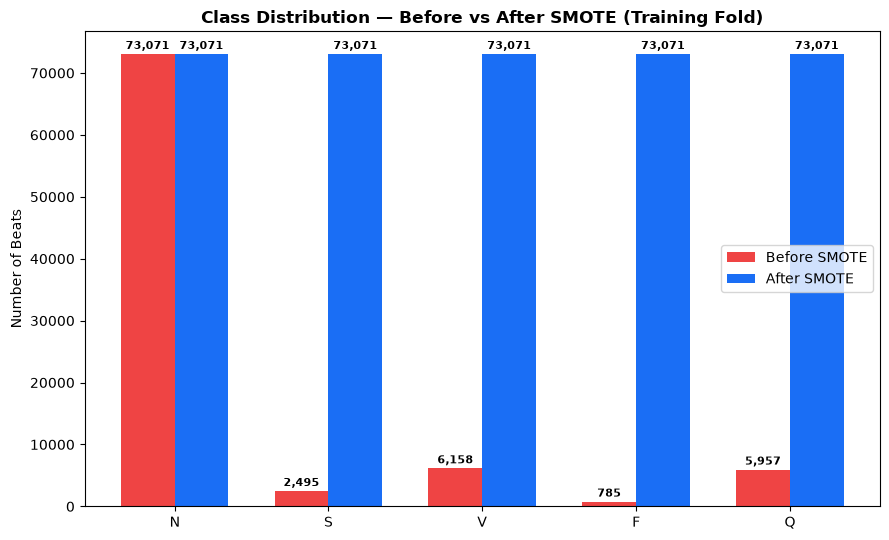

In [22]:
classes = ['N', 'S', 'V', 'F', 'Q']

before_counts = pd.Series(y_train).value_counts()
after_counts = pd.Series(y_train_balanced_labels).value_counts()

before_vals = [before_counts.get(c, 0) for c in classes]
after_vals = [after_counts.get(c, 0) for c in classes]

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, before_vals, width, label='Before SMOTE', color='#ef4444')
bars2 = ax.bar(x + width/2, after_vals, width, label='After SMOTE', color='#1a6ef5')

ax.set_title('Class Distribution — Before vs After SMOTE (Training Fold)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Beats')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,}',
             ha='center', fontsize=8, fontweight='bold')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 800, f'{h:,}',
             ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('smote_before_after.png', dpi=150)
plt.show()

## PHASE 4 : Architecture Implementation & Tuning

### Hyperparameter Search (grouped 3-fold inner CV)
#### Cross-validated grid search over MLP, 1D-CNN and LSTM, selected by macro-F1. Patient-grouped inner folds keep it leakage-free. Run this before the model cells below, then copy the best config into `build_mlp`/`build_cnn`/`build_lstm` in the Phase 5 10-fold evaluation cell.

In [23]:
# Hyperparameter search — grouped 3-fold inner CV, selected by macro-F1
import numpy as np, pandas as pd, time, keras
from itertools import product
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

INNER_SPLITS, EPOCHS, PATIENCE, N_CLASSES, RNG = 3, 25, 4, 5, 42

le    = LabelEncoder().fit(beat_labels)     # fixed encoding for the whole search
y_all = le.transform(beat_labels)


def zscore_beats(x):
    """Per-beat standardisation; uses only each beat's own stats (leakage-free)."""
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True) + 1e-8
    return (x - m) / s


def es():
    return EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True)


# ---------- parameterised builders (same shapes as your main cells) ----------
def build_mlp(u1, u2, dr):
    m = models.Sequential([layers.Input((12,)),
        layers.Dense(u1, 'relu'), layers.Dropout(dr),
        layers.Dense(u2, 'relu'), layers.Dropout(dr * 0.66),
        layers.Dense(N_CLASSES, 'softmax')])
    m.compile('adam', 'sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='acc')])
    return m


def build_cnn(f1, f2, dr):
    m = models.Sequential([layers.Input((234, 1)),
        layers.Conv1D(f1, 7, activation='relu'), layers.MaxPooling1D(2),
        layers.Conv1D(f2, 5, activation='relu'), layers.MaxPooling1D(2),
        layers.Flatten(), layers.Dense(64, 'relu'), layers.Dropout(dr),
        layers.Dense(N_CLASSES, 'softmax')])
    m.compile('adam', 'sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='acc')])
    return m


def build_lstm(u, dr):
    m = models.Sequential([layers.Input((234, 1)),
        layers.LSTM(u), layers.Dropout(dr),
        layers.Dense(32, 'relu'), layers.Dense(N_CLASSES, 'softmax')])
    m.compile('adam', 'sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='acc')])
    return m


# ---------- search space (small on purpose) ----------
CONFIGS = {
    'MLP':  [((u1, u2), dr) for (u1, u2), dr in product([(64, 32), (128, 64)], [0.3, 0.5])],  # 4
    'CNN':  [((f1, f2), dr) for (f1, f2), dr in product([(32, 64), (64, 128)], [0.3, 0.5])],  # 4
    'LSTM': [(u, dr)        for  u,      dr in product([32, 64],              [0.3])],         # 2
}

inner = StratifiedGroupKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=RNG)
FOLDS = list(inner.split(beats, y_all, groups=patient_ids))


def eval_mlp(cfg):
    """Engineered features + adaptive SMOTE + StandardScaler (train-fold only)."""
    (u1, u2), dr = cfg
    scores = []
    for tr, va in FOLDS:
        Xtr, ytr = feature_df.iloc[tr], y_all[tr]
        Xva, yva = feature_df.iloc[va], y_all[va]
        k = max(1, min(5, pd.Series(ytr).value_counts().min() - 1))
        try:
            Xb, yb = SMOTE(random_state=RNG, k_neighbors=k).fit_resample(Xtr, ytr)
        except ValueError:
            Xb, yb = Xtr, ytr                       # fold too sparse for SMOTE
        Xt, Xv, yt, yv = train_test_split(Xb, yb, test_size=0.1,
                                          stratify=yb, random_state=RNG)
        sc = StandardScaler().fit(Xt)
        m = build_mlp(u1, u2, dr)
        m.fit(sc.transform(Xt), yt, validation_data=(sc.transform(Xv), yv),
              epochs=EPOCHS, batch_size=128, callbacks=[es()], verbose=0)
        p = np.argmax(m.predict(sc.transform(Xva), verbose=0), axis=1)
        scores.append(f1_score(yva, p, average='macro'))
        keras.backend.clear_session()
    return float(np.mean(scores)), float(np.std(scores))


def eval_seq(builder, cfg):
    """Raw z-scored beats + balanced class weights (CNN / LSTM)."""
    scores = []
    for tr, va in FOLDS:
        Xtr = zscore_beats(beats[tr])[..., None]; ytr = y_all[tr]
        Xva = zscore_beats(beats[va])[..., None]; yva = y_all[va]
        cw = dict(enumerate(compute_class_weight('balanced',
                            classes=np.unique(ytr), y=ytr)))
        Xt, Xv, yt, yv = train_test_split(Xtr, ytr, test_size=0.1,
                                          stratify=ytr, random_state=RNG)
        m = builder(cfg)
        m.fit(Xt, yt, validation_data=(Xv, yv), epochs=EPOCHS, batch_size=128,
              class_weight=cw, callbacks=[es()], verbose=0)
        p = np.argmax(m.predict(Xva, verbose=0), axis=1)
        scores.append(f1_score(yva, p, average='macro'))
        keras.backend.clear_session()
    return float(np.mean(scores)), float(np.std(scores))


cnn_builder  = lambda cfg: build_cnn(cfg[0][0], cfg[0][1], cfg[1])
lstm_builder = lambda cfg: build_lstm(cfg[0], cfg[1])

# ---------- run the search ----------
best = {}
for name in ['MLP', 'CNN', 'LSTM']:
    print(f"\n=== searching {name} ({len(CONFIGS[name])} configs, "
          f"{INNER_SPLITS}-fold inner CV) ===")
    rows = []
    for cfg in CONFIGS[name]:
        t0 = time.time()
        if name == 'MLP':
            mean, std = eval_mlp(cfg)
        elif name == 'CNN':
            mean, std = eval_seq(cnn_builder, cfg)
        else:
            mean, std = eval_seq(lstm_builder, cfg)
        rows.append((cfg, mean, std))
        print(f"  {str(cfg):24s} macro-F1 = {mean:.3f} +/- {std:.3f}  "
              f"({time.time() - t0:.0f}s)")
    rows.sort(key=lambda r: r[1], reverse=True)
    best[name] = rows[0]
    print(f"  >>> best {name}: {rows[0][0]}  macro-F1 = {rows[0][1]:.3f}")

print("\n================ best configuration per model ================")
for name, (cfg, mean, std) in best.items():
    print(f"{name:5s} {str(cfg):26s} macro-F1 = {mean:.3f} +/- {std:.3f}")
print("\nPlug these into build_mlp / build_cnn / build_lstm in your 10-fold "
      "evaluation cell, then re-run the final comparison + Wilcoxon test.")

I0000 00:00:1783856989.850844    1039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783856990.271400    1039 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783856992.736236    1039 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



=== searching MLP (4 configs, 3-fold inner CV) ===


I0000 00:00:1783856996.919077    1039 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1783856999.307047    2461 service.cc:153] XLA service 0x74d8c40319f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783856999.307087    2461 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783856999.351414    2461 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783856999.506723    2461 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783856999.566181    2461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1358__.15
I0000 00:00:1783857000.27208

  ((64, 32), 0.3)          macro-F1 = 0.340 +/- 0.056  (501s)


I0000 00:00:1783857495.056843    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_741421__.15
I0000 00:00:1783857502.294787    2460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_741421__.15
I0000 00:00:1783857656.140007    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_984590__.15
I0000 00:00:1783857663.703966    2460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_984590__.15
I0000 00:00:1783857824.550558    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1237868__.15
I0000 00:00:1783857831.750553    2461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1237868__.15


...

  ((32, 64), 0.5)          macro-F1 = 0.442 +/- 0.042  (166s)


I0000 00:00:1783859384.556671    2461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3290107__.31
I0000 00:00:1783859391.804386    2460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3290107__.31
I0000 00:00:1783859453.606380    2462 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3346897__.31
I0000 00:00:1783859457.844927    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3346897__.31
I0000 00:00:1783859495.196039    2458 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3384864__.31
I0000 00:00:1783859499.642390    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3384864__.31


  ((64, 128), 0.3)         macro-F1 = 0.446 +/- 0.049  (174s)


I0000 00:00:1783859558.968022    2462 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3444096__.31
I0000 00:00:1783859563.582923    2459 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3444096__.31
I0000 00:00:1783859614.695086    2461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3496208__.31
I0000 00:00:1783859619.169529    2461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3496208__.31
I0000 00:00:1783859674.215528    2460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3552471__.31
I0000 00:00:1783859678.706805    2460 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3552471__.31


  ((64, 128), 0.5)         macro-F1 = 0.438 +/- 0.040  (158s)
  >>> best CNN: ((32, 64), 0.3)  macro-F1 = 0.455

=== searching LSTM (2 configs, 3-fold inner CV) ===
  (32, 0.3)                macro-F1 = 0.350 +/- 0.093  (869s)
  (64, 0.3)                macro-F1 = 0.366 +/- 0.100  (731s)
  >>> best LSTM: (64, 0.3)  macro-F1 = 0.366

================ best configuration per model ================
MLP   ((64, 32), 0.5)            macro-F1 = 0.356 +/- 0.060
CNN   ((32, 64), 0.3)            macro-F1 = 0.455 +/- 0.060
LSTM  (64, 0.3)                  macro-F1 = 0.366 +/- 0.100

Plug these into build_mlp / build_cnn / build_lstm in your 10-fold evaluation cell, then re-run the final comparison + Wilcoxon test.


### MLP Baseline (engineered features + SMOTE)

#### The MLP takes a flat feature vector, not a raw waveform. Your input dimension is 12 (5 time + 2 frequency + 5 wavelet features).
#### Architecture: input(12) → Dense(64, relu) → Dropout → Dense(32, relu) → Dense(5, softmax).
#### Train on X_train_balanced / y_train_balanced (the SMOTE output), evaluate on the untouched test fold. Never apply SMOTE to the test set.

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Encode test labels with the SAME encoder used for training
y_test_encoded = le.transform(y_test)

# Stratified validation slice for early stopping (carved from the SMOTE'd train set)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_balanced, y_train_balanced,
    test_size=0.1, stratify=y_train_balanced, random_state=42)

# Scale features (fit on the training slice only), then reuse for val + test
scaler = StandardScaler().fit(X_tr)
X_test_scaled = scaler.transform(feature_df.iloc[test_idx])

# Build MLP
mlp = models.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
])
mlp.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_mlp = mlp.fit(
    scaler.transform(X_tr), y_tr,
    validation_data=(scaler.transform(X_val), y_val),
    epochs=40, batch_size=128, callbacks=[es], verbose=1
)

test_loss, test_acc = mlp.evaluate(X_test_scaled, y_test_encoded)
print(f"MLP stopped at epoch {len(history_mlp.history['loss'])} | test accuracy: {test_acc:.4f}")


Epoch 1/40


I0000 00:00:1783842404.589590    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19658618__.15


2568/2569 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8118 - loss: 0.5238

I0000 00:00:1783842416.286795    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19658618__.15
I0000 00:00:1783842416.496309    4504 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783842417.020943  202798 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 44 bytes spill stores, 44 bytes spill loads



2569/2569 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8118 - loss: 0.5238

I0000 00:00:1783842421.533909    4504 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2569/2569 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.8118 - loss: 0.5238 - val_accuracy: 0.8860 - val_loss: 0.3170
Epoch 2/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8694 - loss: 0.3653 - val_accuracy: 0.9003 - val_loss: 0.2722
Epoch 3/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8829 - loss: 0.3291 - val_accuracy: 0.9089 - val_loss: 0.2498
Epoch 4/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8894 - loss: 0.3084 - val_accuracy: 0.9138 - val_loss: 0.2338
Epoch 5/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8947 - loss: 0.2960 - val_accuracy: 0.9150 - val_loss: 0.2258
Epoch 6/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8972 - loss: 0.2881 - val_accuracy: 0.9183 - val_loss: 0.2191
Epoch 7/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8993 - loss: 0.2819 - val_accuracy: 0.9200 - val_loss: 0.2124
Epoch 8/40
2569/2569 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9016 - loss: 0.2757 - val_accur

### 1D-CNN (raw beats + class weights)

##### Input is the raw beat: shape (234, 1) — 234 time steps, 1 channel.

##### Conv1D layers slide filters across the waveform to detect QRS-scale patterns. Then pooling reduces length, and dense layers classify.

##### Class weights: compute from the ORIGINAL imbalanced training labels (not SMOTE'd) and pass to model.fit(class_weight=...). This is the sequence-model alternative to SMOTE.

In [31]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Reshape raw beats for Conv1D: (samples, 234, 1)
X_train_seq = beats[train_idx][..., np.newaxis]
X_test_seq = beats[test_idx][..., np.newaxis]
y_train_seq = le.transform(y_train)   # original labels, NOT smote'd
y_test_seq = le.transform(y_test)

# Class weights from the imbalanced training distribution
weights = compute_class_weight('balanced',
                               classes=np.unique(y_train_seq),
                               y=y_train_seq)
class_weight = dict(enumerate(weights))
print("Class weights:", class_weight)

# Stratified validation slice for early stopping
X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
    X_train_seq, y_train_seq,
    test_size=0.1, stratify=y_train_seq, random_state=42)

cnn = models.Sequential([
    layers.Input(shape=(234, 1)),
    layers.Conv1D(32, kernel_size=7, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])
cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_cnn = cnn.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_val, y_seq_val),
    epochs=40, batch_size=128,
    class_weight=class_weight, callbacks=[es], verbose=1
)
print(f"CNN stopped at epoch {len(history_cnn.history['loss'])} | "
      f"test accuracy: {cnn.evaluate(X_test_seq, y_test_seq, verbose=0)[1]:.4f}")


Class weights: {0: np.float64(22.539108280254776), 1: np.float64(0.2421370995333306), 2: np.float64(2.9701527614571095), 3: np.float64(7.091462925851704), 4: np.float64(2.8732055862292953)}
Epoch 1/40


I0000 00:00:1783840264.761045    4505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18866717__.31


614/623 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7805 - loss: 0.4821

I0000 00:00:1783840277.695835    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18866717__.31


623/623 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7820 - loss: 0.4795 - val_accuracy: 0.9378 - val_loss: 0.2799
Epoch 2/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8823 - loss: 0.2720 - val_accuracy: 0.9352 - val_loss: 0.2491
Epoch 3/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9016 - loss: 0.2192 - val_accuracy: 0.9528 - val_loss: 0.1746
Epoch 4/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9113 - loss: 0.1818 - val_accuracy: 0.9300 - val_loss: 0.2228
Epoch 5/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9258 - loss: 0.1609 - val_accuracy: 0.9011 - val_loss: 0.3078
Epoch 6/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9301 - loss: 0.1443 - val_accuracy: 0.9648 - val_loss: 0.1212
Epoch 7/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9319 - loss: 0.1351 - val_accuracy: 0.9585 - val_loss: 0.1333
Epoch 8/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9390 - loss: 0.1221 - val_accuracy: 0.9615 - va

### LSTM (raw beats + class weights)

#### Input shape (234, 1) — same as CNN. The LSTM processes the 234 samples in order, maintaining a hidden state that captures how the signal evolves through the beat.

#### LSTMs are slower to train than CNNs. Start with a single LSTM layer (64 units); only stack a second if underfitting. Keep the same class_weight approach so the three-way comparison is fair.

In [32]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Reuse the same stratified validation slice policy as the CNN
X_seq_tr, X_seq_val, y_seq_tr, y_seq_val = train_test_split(
    X_train_seq, y_train_seq,
    test_size=0.1, stratify=y_train_seq, random_state=42)

lstm = models.Sequential([
    layers.Input(shape=(234, 1)),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(5, activation='softmax')
])
lstm.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_lstm = lstm.fit(
    X_seq_tr, y_seq_tr,
    validation_data=(X_seq_val, y_seq_val),
    epochs=40, batch_size=128,
    class_weight=class_weight, callbacks=[es], verbose=1
)
print(f"LSTM stopped at epoch {len(history_lstm.history['loss'])} | "
      f"test accuracy: {lstm.evaluate(X_test_seq, y_test_seq, verbose=0)[1]:.4f}")


Epoch 1/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.2417 - loss: 1.1758 - val_accuracy: 0.4576 - val_loss: 1.2694
Epoch 2/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.4777 - loss: 0.9364 - val_accuracy: 0.5776 - val_loss: 1.1781
Epoch 3/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5971 - loss: 0.8204 - val_accuracy: 0.6022 - val_loss: 1.0897
Epoch 4/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2877 - loss: 1.5164 - val_accuracy: 0.1927 - val_loss: 1.5745
Epoch 5/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2732 - loss: 1.3963 - val_accuracy: 0.3897 - val_loss: 1.3926
Epoch 6/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.2317 - loss: 1.4459 - val_accuracy: 0.0488 - val_loss: 1.5533
Epoch 7/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.1512 - loss: 1.3999 - val_accuracy: 0.0963 - val_loss: 1.5080
Epoch 8/40
623/623 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.1198 - loss: 1.3067 - 

## PHASE 5 : Comparative Evaluation

### Per-Class Metrics & Confusion Matrices

#### sklearn's classification_report gives per-class precision, recall, and F1 in one call. The confusion matrix shows exactly which classes get confused with which.

#### Watch especially for: S predicted as N (a known hard case), and F (fusion) recall — F is your rarest class at 785 training beats, so it's the toughest test of whether imbalance handling worked.

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

===== MLP =====
              precision    recall  f1-score   support

           F      0.002     0.059     0.005        17
           N      0.957     0.700     0.808     17524
           Q      0.727     0.876     0.794      2084
           S      0.022     0.028     0.025       286
           V      0.174     0.794     0.286      1077

    accuracy                          0.712     20988
   macro avg      0.377     0.491     0.384     20988
weighted avg      0.881     0.712     0.769     20988



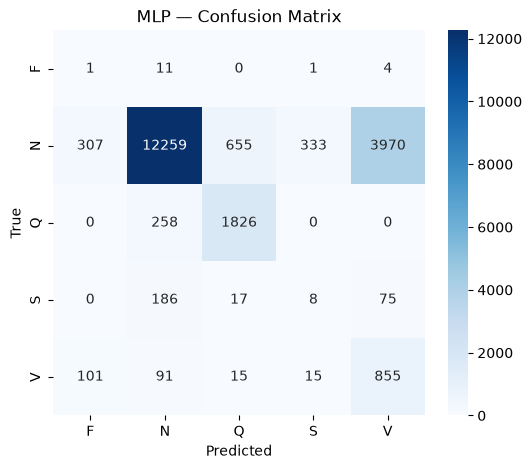

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

===== CNN =====
              precision    recall  f1-score   support

           F      0.045     0.059     0.051        17
           N      0.981     0.627     0.765     17524
           Q      0.985     0.892     0.936      2084
           S      0.092     0.322     0.143       286
           V      0.128     0.817     0.221      1077

    accuracy                          0.658     20988
   macro avg      0.446     0.543     0.423     20988
weighted avg      0.925     0.658     0.745     20988



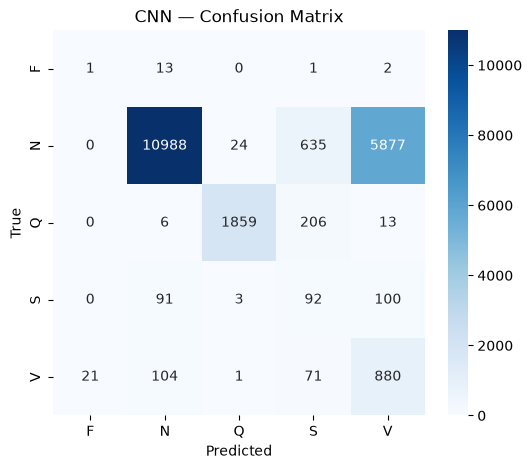

656/656 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step

===== LSTM =====
              precision    recall  f1-score   support

           F      0.001     0.059     0.002        17
           N      0.941     0.513     0.664     17524
           Q      0.188     0.009     0.017      2084
           S      0.010     0.238     0.019       286
           V      0.163     0.521     0.249      1077

    accuracy                          0.459     20988
   macro avg      0.261     0.268     0.190     20988
weighted avg      0.813     0.459     0.569     20988



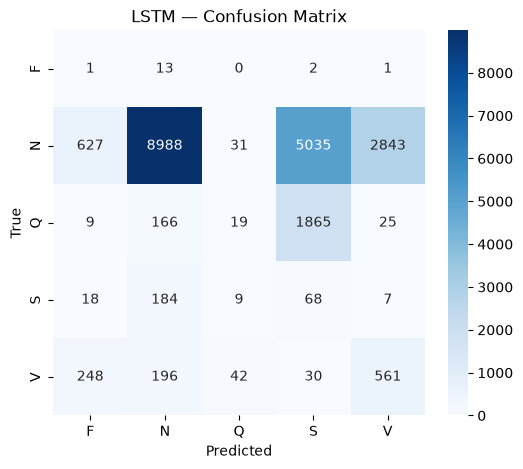

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

labels = list(le.classes_)

for name, model, X_eval, y_eval in [
    ('MLP', mlp, X_test_scaled, y_test_encoded),
    ('CNN', cnn, X_test_seq, y_test_seq),
    ('LSTM', lstm, X_test_seq, y_test_seq)
]:
    y_pred = np.argmax(model.predict(X_eval), axis=1)
    print(f"\n===== {name} =====")
    print(classification_report(y_eval, y_pred, target_names=labels, digits=3))

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.savefig(f'cm_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

### Head-to-Head Comparison Table & Plot

#### Use MACRO-averaged F1 (unweighted mean across classes) as your headline metric, not accuracy or weighted-F1 — macro-F1 treats every class equally, so it rewards models that handle the rare arrhythmias well.

#### Collect the three models' macro-F1 (and per-class F1) into one dataframe and plot side by side. This is the figure your supervisor and examiner will look at first.

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step
          F      N      Q      S      V  MACRO-F1
MLP   0.005  0.808  0.794  0.025  0.286     0.384
CNN   0.051  0.765  0.936  0.143  0.221     0.423
LSTM  0.002  0.664  0.017  0.019  0.249     0.190


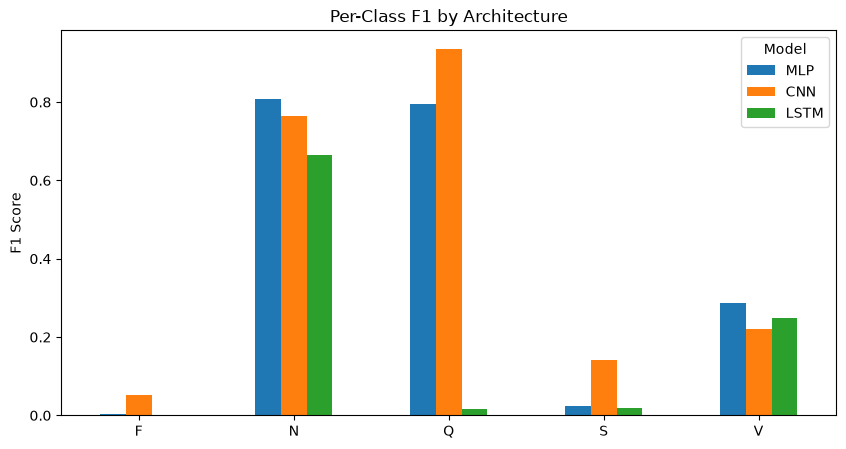

In [36]:
from sklearn.metrics import f1_score

results = {}
for name, model, X_eval, y_eval in [
    ('MLP', mlp, X_test_scaled, y_test_encoded),
    ('CNN', cnn, X_test_seq, y_test_seq),
    ('LSTM', lstm, X_test_seq, y_test_seq)
]:
    y_pred = np.argmax(model.predict(X_eval), axis=1)
    per_class = f1_score(y_eval, y_pred, average=None)
    macro = f1_score(y_eval, y_pred, average='macro')
    results[name] = list(per_class) + [macro]

class_names = list(le.classes_)
comparison = pd.DataFrame(results, index=class_names + ['MACRO-F1']).T
print(comparison.round(3))

comparison[class_names].T.plot(kind='bar', figsize=(10,5))
plt.title('Per-Class F1 by Architecture')
plt.ylabel('F1 Score'); plt.xticks(rotation=0)
plt.legend(title='Model')
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Per-Beat Z-Score Normalisation (raw CNN/LSTM inputs)
#### Each raw beat is standardised to zero mean and unit variance using only its own statistics, so there is no train/test leakage. This implements the per-beat standardisation stated in the methodology and stabilises training for the sequence models.

In [37]:
def zscore_beats(x):
    """Per-beat standardisation: each beat -> zero mean, unit variance.
    Uses only the beat's own statistics, so it is leakage-free."""
    m = x.mean(axis=1, keepdims=True)
    s = x.std(axis=1, keepdims=True) + 1e-8
    return (x - m) / s


### Stratified-Group 10-Fold Evaluation & Significance Testing
#### Patient-wise, stratified 10-fold cross-validation (`StratifiedGroupKFold`). For each fold and model it records per-class sensitivity/specificity, macro-F1, macro AUC-ROC, Cohen's Kappa, and the confusion matrix, then runs a paired Wilcoxon signed-rank test (Holm-corrected, alpha = 0.05) on the per-fold macro-F1 values. Raw CNN/LSTM inputs are per-beat normalised via `zscore_beats`. 


In [38]:
# Stratified-Group 10-fold CV + significance
import keras
import time, pickle, os
from tensorflow.keras import backend as K
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, cohen_kappa_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from scipy.stats import wilcoxon
from itertools import combinations
from statsmodels.stats.multitest import multipletests

CAP_EPOCHS = 40         # upper limit; early stopping usually ends sooner
PATIENCE   = 5          # stop after this many epochs with no val_loss gain
N_SPLITS   = 10
N_CLASSES  = 5

def make_es():
    # fresh callback per fit; restores the best-val_loss weights
    return EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True)

le = LabelEncoder().fit(beat_labels)          # fixed encoding across all folds
CLASS_NAMES = list(le.classes_)

def build_mlp():
    m = models.Sequential([layers.Input((12,)),
        layers.Dense(64, 'relu'), layers.Dropout(0.3),
        layers.Dense(32, 'relu'), layers.Dropout(0.2),
        layers.Dense(5, 'softmax')])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    return m

def build_cnn():
    m = models.Sequential([layers.Input((234, 1)),
        layers.Conv1D(32, 7, activation='relu'), layers.MaxPooling1D(2),
        layers.Conv1D(64, 5, activation='relu'), layers.MaxPooling1D(2),
        layers.Flatten(), layers.Dense(64, 'relu'), layers.Dropout(0.3),
        layers.Dense(5, 'softmax')])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    return m

def build_lstm():
    m = models.Sequential([layers.Input((234, 1)),
        layers.LSTM(64), layers.Dropout(0.3),
        layers.Dense(32, 'relu'), layers.Dense(5, 'softmax')])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    return m

def metrics(y_true, y_proba):
    y_pred = np.argmax(y_proba, axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(N_CLASSES))
    sens, spec = [], []
    for i in range(N_CLASSES):
        TP = cm[i, i]; FN = cm[i, :].sum() - TP; FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        sens.append(TP / (TP + FN) if TP + FN else np.nan)
        spec.append(TN / (TN + FP) if TN + FP else np.nan)
    present = np.unique(y_true)
    if len(present) < 2:
        auc = np.nan
    else:
        auc = float(np.mean([
            roc_auc_score((y_true == c).astype(int), y_proba[:, c])
            for c in present
        ]))
    return {'macro_f1': f1_score(y_true, y_pred, average='macro'),
            'kappa': cohen_kappa_score(y_true, y_pred),
            'macro_auc': auc, 'sens': sens, 'spec': spec, 'cm': cm}

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
CKPT = 'cv_rows.pkl'

# resume if a previous run left a checkpoint
if os.path.exists(CKPT):
    with open(CKPT, 'rb') as f:
        rows = pickle.load(f)
    done = min(len(rows[m]) for m in rows)          # folds fully completed
    for m in rows: rows[m] = rows[m][:done]         # drop any half-written fold
    print(f"Resuming: {done} folds already done")
else:
    rows = {m: [] for m in ['MLP', 'CNN', 'LSTM']}
    done = 0

cm_sum = {m: sum((r['cm'] for r in rows[m]), np.zeros((N_CLASSES, N_CLASSES), int))
          for m in rows}

for k, (tr, te) in enumerate(sgkf.split(beats, beat_labels, groups=patient_ids)):
    if k < done:
        continue                                    # already computed, skip
    K.clear_session()                               # free the previous fold's graph
    t_fold = time.time()
    y_tr = le.transform(beat_labels[tr]); y_te = le.transform(beat_labels[te])
    ran = {}

    # ---- MLP: engineered features + SMOTE + scaling (fit on train only) ----
    min_count = pd.Series(y_tr).value_counts().min()
    k_nn = max(1, min(5, min_count - 1))
    try:
        Xtr_bal, ytr_bal = SMOTE(random_state=42, k_neighbors=k_nn).fit_resample(
            feature_df.iloc[tr], y_tr)
    except ValueError:
        Xtr_bal, ytr_bal = feature_df.iloc[tr], y_tr   # fold too sparse for SMOTE
    Xtr_f, Xval_f, ytr_f, yval_f = train_test_split(
        Xtr_bal, ytr_bal, test_size=0.1, stratify=ytr_bal, random_state=42)
    sc = StandardScaler().fit(Xtr_f)               # scaler fit on train slice only
    mdl = build_mlp()
    h = mdl.fit(sc.transform(Xtr_f), ytr_f,
                validation_data=(sc.transform(Xval_f), yval_f),
                epochs=CAP_EPOCHS, batch_size=128,
                callbacks=[make_es()], verbose=1)
    ran['MLP'] = len(h.history['loss'])
    proba = mdl.predict(sc.transform(feature_df.iloc[te]), verbose=0)
    r = metrics(y_te, proba); rows['MLP'].append(r); cm_sum['MLP'] += r['cm']

    # ---- CNN / LSTM: raw beats (per-beat z-scored) + class weights ----
    Xtr_s = zscore_beats(beats[tr])[..., None]
    Xte_s = zscore_beats(beats[te])[..., None]
    cw = dict(enumerate(compute_class_weight('balanced',
              classes=np.unique(y_tr), y=y_tr)))
    Xt_tr, Xt_val, yt_tr, yt_val = train_test_split(
        Xtr_s, y_tr, test_size=0.1, stratify=y_tr, random_state=42)
    for name, build in [('CNN', build_cnn), ('LSTM', build_lstm)]:
        t = time.time()
        mdl = build()
        h = mdl.fit(Xt_tr, yt_tr, validation_data=(Xt_val, yt_val),
                    epochs=CAP_EPOCHS, batch_size=128, class_weight=cw,
                    callbacks=[make_es()], verbose=1)
        ran[name] = len(h.history['loss'])
        proba = mdl.predict(Xte_s, verbose=1)
        r = metrics(y_te, proba); rows[name].append(r); cm_sum[name] += r['cm']
        print(f"  fold {k} {name}: {time.time()-t:.0f}s ({ran[name]} ep)", flush=True)

    with open(CKPT, 'wb') as f:                      # save after every fold
        pickle.dump(rows, f)
    print(f"fold {k} done in {(time.time()-t_fold)/60:.1f} min | " + " | ".join(
        f"{n} F1={rows[n][-1]['macro_f1']:.3f} (stopped@{ran[n]})" for n in rows), flush=True)

# ---- summary: mean +/- std across folds ----
summary = pd.DataFrame({
    n: {'macro_F1': np.mean([r['macro_f1'] for r in rows[n]]),
        'macro_F1_std': np.std([r['macro_f1'] for r in rows[n]]),
        'kappa': np.mean([r['kappa'] for r in rows[n]]),
        'macro_AUC': np.nanmean([r['macro_auc'] for r in rows[n]])}
    for n in rows}).T
print("\n=== 10-fold cross-validated performance ===\n", summary.round(3))

# ---- per-class sensitivity / specificity (mean over folds) ----
for n in rows:
    sens = np.nanmean([r['sens'] for r in rows[n]], axis=0)
    spec = np.nanmean([r['spec'] for r in rows[n]], axis=0)
    print(f"\n{n} per-class:")
    print(pd.DataFrame({'sensitivity': sens, 'specificity': spec},
                       index=CLASS_NAMES).round(3))

# ---- paired Wilcoxon on per-fold macro-F1 + Holm correction ----
macro = pd.DataFrame({n: [r['macro_f1'] for r in rows[n]] for n in rows})
pairs, pv = [], []
for a, b in combinations(['CNN', 'MLP', 'LSTM'], 2):
    _, p = wilcoxon(macro[a], macro[b]); pairs.append(f"{a} vs {b}"); pv.append(p)
_, p_holm, _, _ = multipletests(pv, method='holm')
print("\n=== Paired Wilcoxon signed-rank (macro-F1, alpha=0.05) ===")
for pr, p, ph in zip(pairs, pv, p_holm):
    print(f"{pr:14} raw p={p:.4f}  Holm p={ph:.4f}  -> "
          f"{'significant' if ph < 0.05 else 'n.s.'}")


Resuming: 1 folds already done
Epoch 1/40


I0000 00:00:1783802924.759416   14603 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_586249__.15


2835/2836 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8045 - loss: 0.5422

I0000 00:00:1783802936.530502   14608 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_586249__.15
I0000 00:00:1783802936.808442   14608 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


2836/2836 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8045 - loss: 0.5421 - val_accuracy: 0.8780 - val_loss: 0.3417
Epoch 2/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8589 - loss: 0.3956 - val_accuracy: 0.8957 - val_loss: 0.2981
Epoch 3/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8728 - loss: 0.3605 - val_accuracy: 0.9036 - val_loss: 0.2771
Epoch 4/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8793 - loss: 0.3439 - val_accuracy: 0.9072 - val_loss: 0.2634
Epoch 5/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8832 - loss: 0.3319 - val_accuracy: 0.9102 - val_loss: 0.2546
Epoch 6/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8850 - loss: 0.3248 - val_accuracy: 0.9127 - val_loss: 0.2455
Epoch 7/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8866 - loss: 0.3197 - val_accuracy: 0.9139 - val_loss: 0.2408
Epoch 8/40
2836/2836 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8885 - loss: 0.3145 - val_a

...

2887/2887 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8091 - loss: 0.5305 - val_accuracy: 0.8820 - val_loss: 0.3275
Epoch 2/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8596 - loss: 0.3913 - val_accuracy: 0.8944 - val_loss: 0.2880
Epoch 3/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8726 - loss: 0.3559 - val_accuracy: 0.9036 - val_loss: 0.2653
Epoch 4/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8785 - loss: 0.3388 - val_accuracy: 0.9087 - val_loss: 0.2509
Epoch 5/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8823 - loss: 0.3271 - val_accuracy: 0.9136 - val_loss: 0.2429
Epoch 6/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8852 - loss: 0.3178 - val_accuracy: 0.9153 - val_loss: 0.2317
Epoch 7/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8878 - loss: 0.3101 - val_accuracy: 0.9175 - val_loss: 0.2262
Epoch 8/40
2887/2887 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8902 - loss: 0.3031 - val

I0000 00:00:1783809464.621660   14604 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5943575__.31


698/707 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7831 - loss: 0.4954

I0000 00:00:1783809471.733846   14609 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_5943575__.31


707/707 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.7845 - loss: 0.4924 - val_accuracy: 0.9421 - val_loss: 0.2283
Epoch 2/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8790 - loss: 0.2941 - val_accuracy: 0.9067 - val_loss: 0.2994
Epoch 3/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9061 - loss: 0.2313 - val_accuracy: 0.9612 - val_loss: 0.1620
Epoch 4/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9179 - loss: 0.1985 - val_accuracy: 0.9494 - val_loss: 0.1529
Epoch 5/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9267 - loss: 0.1775 - val_accuracy: 0.9381 - val_loss: 0.1786
Epoch 6/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9365 - loss: 0.1546 - val_accuracy: 0.9674 - val_loss: 0.1080
Epoch 7/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9401 - loss: 0.1415 - val_accuracy: 0.9624 - val_loss: 0.1195
Epoch 8/40
707/707 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9389 - loss: 0.1364 - val_accuracy: 0.9246 - va

### Feature-Domain Ablation (MLP)
#### Isolates the contribution of each feature domain by training the MLP separately on time-only, frequency-only, wavelet-only, and combined features across the same stratified-group 10-fold splits. 

In [29]:
# feature-domain ablation (MLP) - time vs freq vs wavelet vs all
import keras
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

CAP_EPOCHS, PATIENCE, N_SPLITS = 40, 5, 10
le = LabelEncoder().fit(beat_labels)

domains = {
    'time':    ['mean', 'std', 'skew', 'kurtosis', 'rms'],
    'freq':    ['dominant_freq', 'spectral_energy'],
    'wavelet': [c for c in feature_df.columns if c.startswith('wavelet_energy')],
}
domains['all'] = domains['time'] + domains['freq'] + domains['wavelet']

def mlp(input_dim):
    m = models.Sequential([layers.Input((input_dim,)),
        layers.Dense(64, 'relu'), layers.Dropout(0.3),
        layers.Dense(32, 'relu'), layers.Dropout(0.2),
        layers.Dense(5, 'softmax')])
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')])
    return m

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
ablation = {d: [] for d in domains}

for k, (tr, te) in enumerate(sgkf.split(feature_df, beat_labels, groups=patient_ids)):
    y_tr, y_te = le.transform(beat_labels[tr]), le.transform(beat_labels[te])
    for d, cols in domains.items():
        Xtr, Xte = feature_df[cols].iloc[tr], feature_df[cols].iloc[te]

        # adaptive k_neighbors so SMOTE can't fail on a sparse rare class
        min_count = pd.Series(y_tr).value_counts().min()
        k_nn = max(1, min(5, min_count - 1))
        try:
            Xb, yb = SMOTE(random_state=42, k_neighbors=k_nn).fit_resample(Xtr, y_tr)
        except ValueError:
            Xb, yb = Xtr, y_tr                       # fold too sparse for SMOTE

        Xb_tr, Xb_val, yb_tr, yb_val = train_test_split(
            Xb, yb, test_size=0.1, stratify=yb, random_state=42)
        sc = StandardScaler().fit(Xb_tr)
        es = EarlyStopping(monitor='val_loss', patience=PATIENCE,
                           restore_best_weights=True)
        m = mlp(len(cols))
        m.fit(sc.transform(Xb_tr), yb_tr,
              validation_data=(sc.transform(Xb_val), yb_val),
              epochs=CAP_EPOCHS, batch_size=128, callbacks=[es], verbose=0)
        p = np.argmax(m.predict(sc.transform(Xte), verbose=0), axis=1)
        ablation[d].append(f1_score(y_te, p, average='macro'))
    print(f"fold {k}: " + " | ".join(f"{d}={ablation[d][-1]:.3f}" for d in domains))

abl_df = pd.DataFrame(ablation)
print("\n=== domain ablation - macro-F1 (mean +/- std over folds) ===")
print(pd.DataFrame({'mean': abl_df.mean(), 'std': abl_df.std()}).round(3))

I0000 00:00:1783825185.377670    2071 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1783825187.242035    4504 service.cc:153] XLA service 0x7a9ac80425d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783825187.242075    4504 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1783825187.283836    4504 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783825187.441691    4504 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1783825187.496052    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1358__.15
I0000 00:00:1783825188.18860

fold 0: time=0.234 | freq=0.213 | wavelet=0.235 | all=0.256


I0000 00:00:1783826587.548857    4498 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2111898__.15
I0000 00:00:1783826596.890280    4503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2111898__.15
I0000 00:00:1783826597.207859    4503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783826932.503692    4503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2622320__.15
I0000 00:00:1783826941.526813    4505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2622320__.15
I0000 00:00:1783827211.549960    4505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3044165__.15
I0000 00:00:1783827220.821540    4502 dot_merger.cc:481] Merging Dots in compu

fold 1: time=0.354 | freq=0.276 | wavelet=0.565 | all=0.556


I0000 00:00:1783827894.070944    4502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4065057__.15
I0000 00:00:1783827903.534564    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4065057__.15
I0000 00:00:1783827903.961317    4504 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783827904.429376   41790 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 44 bytes spill stores, 44 bytes spill loads

I0000 00:00:1783827908.948242    4504 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the

...

fold 7: time=0.178 | freq=0.268 | wavelet=0.308 | all=0.233


I0000 00:00:1783835524.876875    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15235147__.15
I0000 00:00:1783835534.650710    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15235147__.15
I0000 00:00:1783835535.421229    4504 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783835535.830885  145829 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_20', 44 bytes spill stores, 44 bytes spill loads

I0000 00:00:1783835539.549306    4503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using t

fold 8: time=0.184 | freq=0.260 | wavelet=0.196 | all=0.224


I0000 00:00:1783836777.465288    4498 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17037052__.15
I0000 00:00:1783836787.470461    4503 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_17037052__.15
I0000 00:00:1783836787.526678    4503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783836788.195221    4503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1783836788.708769    4503 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not conta

fold 9: time=0.158 | freq=0.217 | wavelet=0.178 | all=0.305

=== domain ablation - macro-F1 (mean +/- std over folds) ===
          mean    std
time     0.228  0.063
freq     0.226  0.072
wavelet  0.296  0.126
all      0.319  0.102


## PHASE 6 : Error Analysis & Interpretation

### Misclassification Pattern Analysis

#### Look at the off-diagonal cells in your confusion matrices. The common findings in MIT-BIH work:

##### • S ↔ N confusion: supraventricular beats can look almost normal — hardest distinction.
##### • F ↔ V confusion: fusion beats are literally part-ventricular, so overlap is expected.
##### • Q usually easiest: paced beats have a distinctive morphology.

#### Pull actual example waveforms of misclassified beats to show WHY — a misclassified S that visually resembles an N is far more convincing evidence than a number.

656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Confusion matrix (rows = true, cols = predicted):
        pred_F  pred_N  pred_Q  pred_S  pred_V
true_F       1      11       0       0       5
true_N       0   11015      70     295    6144
true_Q       0       8    1807     256      13
true_S       1     107       2      63     113
true_V       5      76       1      13     982 

Row-normalised (fraction of each true class sent to each prediction):
        pred_F  pred_N  pred_Q  pred_S  pred_V
true_F   0.059   0.647   0.000   0.000   0.294
true_N   0.000   0.629   0.004   0.017   0.351
true_Q   0.000   0.004   0.867   0.123   0.006
true_S   0.003   0.374   0.007   0.220   0.395
true_V   0.005   0.071   0.001   0.012   0.912 

Dominant misclassification per true class:
  true F (n=   17):  5.9% correct | most confused with N (64.7%)
  true N (n=17524): 62.9% correct | most confused with V (35.1%)
  true Q (n= 2084): 86.7% correct | most confused with S (12.3%)
  true S (n=  286): 22.0% correct

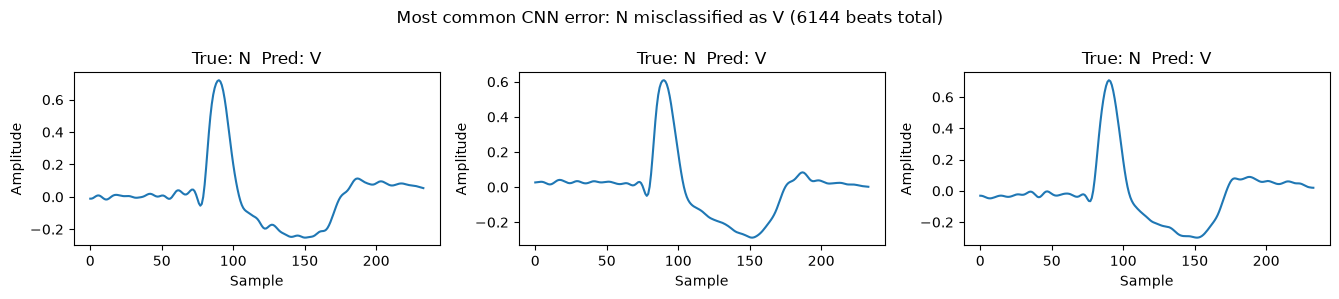

In [32]:
# ── Phase 6: Confusion-matrix-driven error analysis (best model = CNN by macro-F1) ──
from sklearn.metrics import confusion_matrix

class_names = list(le.classes_)                       # ['F','N','Q','S','V']
n_classes = len(class_names)

y_pred_cnn = np.argmax(cnn.predict(X_test_seq), axis=1)

# Rows = TRUE class, cols = PREDICTED class
cm = confusion_matrix(y_test_seq, y_pred_cnn, labels=range(n_classes))
cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in class_names],
                         columns=[f'pred_{c}' for c in class_names])

# Row-normalise: where does each true class's beats actually go?
cm_row_norm = cm_df.div(cm_df.sum(axis=1).replace(0, np.nan), axis=0).round(3)

print("Confusion matrix (rows = true, cols = predicted):")
print(cm_df, "\n")
print("Row-normalised (fraction of each true class sent to each prediction):")
print(cm_row_norm, "\n")

# Dominant error per true class, extracted programmatically
print("Dominant misclassification per true class:")
for t in range(n_classes):
    total = cm[t].sum()
    if total == 0:
        print(f"  {class_names[t]}: no beats in test set")
        continue
    off = cm[t].copy(); off[t] = 0                     # zero the diagonal
    top = int(np.argmax(off))
    print(f"  true {class_names[t]} (n={total:>5}): "
          f"{cm[t][t]/total:5.1%} correct | most confused with "
          f"{class_names[top]} ({off[top]/total:.1%})")

# Single largest off-diagonal error, found from the data itself
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
t_idx, p_idx = np.unravel_index(np.argmax(cm_off), cm_off.shape)
true_lbl, pred_lbl = class_names[t_idx], class_names[p_idx]
print(f"\nLargest single error type: true {true_lbl} predicted as {pred_lbl} "
      f"({cm_off[t_idx, p_idx]} beats)")

# Plot examples of THAT actual error (never blank axes)
examples = np.where((y_test_seq == t_idx) & (y_pred_cnn == p_idx))[0]
n_show = min(3, len(examples))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(4.5 * n_show, 3), squeeze=False)
    for ax, idx in zip(axes[0], examples[:n_show]):
        ax.plot(beats[test_idx][idx])
        ax.set_title(f'True: {true_lbl}  Pred: {pred_lbl}')
        ax.set_xlabel('Sample'); ax.set_ylabel('Amplitude')
    plt.suptitle(f'Most common CNN error: {true_lbl} misclassified as {pred_lbl} '
                 f'({len(examples)} beats total)')
    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No examples of that error type to plot.")

### Did Imbalance Handling Actually Help?

#### Run a quick ablation: train the MLP once WITHOUT SMOTE (on the raw imbalanced features) and compare its minority-class recall against your SMOTE version.
#### If SMOTE lifted F/S recall substantially while barely touching N, that's direct evidence answering your research question "How does SMOTE affect minority-class recognition?" — a concrete, defensible finding rather than an assumption.

In [37]:
# Ablation: MLP without SMOTE, same architecture
from sklearn.metrics import recall_score
from sklearn.preprocessing import StandardScaler

# Dedicated scaler — do NOT refit the global `scaler` (that one belongs to the SMOTE model)
scaler_ns = StandardScaler()
X_train_raw = scaler_ns.fit_transform(feature_df.iloc[train_idx])   # fit on the raw train fold
X_test_raw  = scaler_ns.transform(feature_df.iloc[test_idx])        # test scaled in the SAME space
y_train_raw = le.transform(y_train)

mlp_nosmote = models.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'), layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')
])
mlp_nosmote.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])
mlp_nosmote.fit(X_train_raw, y_train_raw, epochs=30,
                batch_size=128, verbose=0)

# Each model is evaluated in the feature space it was trained in:
#   mlp_nosmote -> X_test_raw    (raw-fit scaler)
#   mlp (SMOTE) -> X_test_scaled (SMOTE-fit scaler, from the SMOTE MLP cell)
mlp_nosmote.fit(X_train_raw, y_train_raw, epochs=30,
                batch_size=128, verbose=0)

# --- retrain the SMOTE MLP locally (cell 65 overwrote the name `mlp`) ---
from imblearn.over_sampling import SMOTE
X_bal, y_bal = SMOTE(random_state=42).fit_resample(
    feature_df.iloc[train_idx], y_train_raw)
scaler_s   = StandardScaler().fit(X_bal)
X_test_s   = scaler_s.transform(feature_df.iloc[test_idx])

mlp_smote = models.Sequential([
    layers.Input(shape=(12,)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'), layers.Dropout(0.2),
    layers.Dense(5, activation='softmax')])
mlp_smote.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
mlp_smote.fit(scaler_s.transform(X_bal), y_bal, epochs=30,
              batch_size=128, verbose=0)

y_pred_ns = np.argmax(mlp_nosmote.predict(X_test_raw), axis=1)
y_pred_s  = np.argmax(mlp_smote.predict(X_test_s),     axis=1)

rec_ns = recall_score(y_test_encoded, y_pred_ns, average=None)
rec_s  = recall_score(y_test_encoded, y_pred_s,  average=None)

comp = pd.DataFrame({'Without SMOTE': rec_ns, 'With SMOTE': rec_s},
                    index=list(le.classes_))   # ['F','N','Q','S','V'] — matches encoded order
print("Per-class RECALL comparison (inter-patient test set):")
print(comp.round(3))

I0000 00:00:1783842755.004072    4505 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20121226__.15
I0000 00:00:1783842758.858987    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20121226__.15
I0000 00:00:1783842877.857961    4502 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20289525__.15
I0000 00:00:1783842887.300765    4504 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_20289525__.15


656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
656/656 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Per-class RECALL comparison (inter-patient test set):
   Without SMOTE  With SMOTE
F          0.000       0.000
N          0.865       0.689
Q          0.024       0.798
S          0.000       0.028
V          0.661       0.802
